# Aula 7 — Relatório analítico de redes sociais

Nas últimas três aulas você coletou dados de rede social (Aula 4), calculou métricas e agrupou por hashtag (Aula 5), e transformou isso em gráfico (Aula 6). Cada peça, sozinha, já responde alguma coisa. Hoje o trabalho é outro: pegar tudo isso e organizar numa peça só, que uma pessoa que não estava na sala consiga ler, entender a pergunta, conferir os dados e não confundir o que foi encontrado com o que foi recomendado.

Não tem coleta nova nem métrica nova hoje. É a aula de arrumar a casa: estrutura de relatório, decisões metodológicas registradas por escrito, revisão por pares e os erros de raciocínio mais comuns nessa hora. No fim, você usa isso tudo no **Projeto 2**, a entrega final do módulo.

## 1. Revisão inicial: o pipeline completo

Antes de escrever relatório, vale ver o caminho inteiro que os dados percorreram até aqui:

**Origem → tratamento → análise → comunicação**

- **Origem** (Aula 4): coleta com Zeeschuimer, um recorte público e combinado em aula, com fonte, período e limites éticos registrados.
- **Tratamento** (Aula 5): conferência de qualidade (tipos, valores ausentes, duplicata), cálculo de métricas com denominador correto.
- **Análise** (Aula 5 e 6): agrupamento por hashtag, tabela-resumo, gráficos que respondem a uma pergunta específica.
- **Comunicação** (hoje): tudo isso organizado num relatório que alguém de fora consegue ler, conferir e usar.

Um relatório analítico não é o passo final por acaso: ele é o que sobra depois que a coleta, a limpeza e o gráfico já fizeram seu trabalho. Se qualquer uma dessas etapas anteriores estiver capenga (dado errado, métrica mal calculada, gráfico sem fonte), o relatório final herda o problema. Por isso a primeira pergunta antes de escrever qualquer relatório é: **os passos anteriores estão registrados o suficiente pra alguém repetir?**

## 2. Preparando o ambiente

Esta aula usa `pandas` e `matplotlib`, os mesmos das Aulas 5 e 6, só para recarregar a tabela-resumo e reaproveitar um gráfico já conhecido. Instale as dependências registradas no `requirements.txt` desta pasta.

No Windows (Prompt de Comando/CMD), **dentro da pasta desta aula:**

```cmd
uv venv .venv
uv pip install -r requirements.txt
```

Se o `uv` não funcionar:

```cmd
pip install -r requirements.txt
```

No Mac (Terminal), os mesmos comandos funcionam.

## 3. Recarregando a tabela-resumo (revisão comprimida)

Isso é só o pipeline das Aulas 5 e 6, resumido em três células, para termos os mesmos dados e o mesmo gráfico à mão na hora de montar o relatório de exemplo mais abaixo. Se algum passo aqui parecer novo, volte no notebook da Aula 5 ou 6.

**OBS:** `dados/exportacao.csv` desta pasta é o mesmo exemplo sintético já usado nas Aulas 5 e 6, para todo mundo conseguir rodar sem depender da própria coleta.

In [2]:
import pandas as pd  # pandas para tabela
import matplotlib.pyplot as plt  # matplotlib para gráfico

df = pd.read_csv("/Users/leonardorosa/estudo/extracao-dados-trabalhos-juliacereja/projetos/07-relatorio-analitico/07-relatorio-analitico/dados/zeeschuimer-export-tiktok.com-2026-08-19T150132.csv", sep=";")  # lê a exportação, mesmo arquivo e separador das aulas anteriores
df = df.drop_duplicates()  # remove linha idêntica a outra anterior, se existir

df_posts = df[df["plays"] > 0].copy()  # só posts com denominador válido para a taxa de engajamento
df_posts["taxa_engajamento"] = (
    df_posts["likes"] + df_posts["comments"] + df_posts["shares"]
) / df_posts["plays"]  # mesma fórmula das Aulas 5 e 6: interações dividido por visualizações

print(f"Linhas depois de remover duplicatas: {len(df)}")
print(f"Posts com visualização válida: {len(df_posts)}")

Linhas depois de remover duplicatas: 1416
Posts com visualização válida: 1416


In [11]:
df_hashtags = df_posts.dropna(subset=["hashtags"]).copy()  # só posts com hashtag preenchida
df_hashtags["hashtags"] = df_hashtags["hashtags"].str.split(",")  # separa a string em lista
df_hashtags = df_hashtags.explode("hashtags")  # uma linha por hashtag
df_hashtags["hashtags"] = df_hashtags["hashtags"].str.strip()  # tira espaço sobrando
df_hashtags = df_hashtags[df_hashtags.groupby("hashtags")["id"].transform("count") >= 20]  # filtra hashtags com pelo menos 5 posts

resumo_hashtags = df_hashtags.groupby("hashtags").agg(  # agrupa por hashtag
    qtd_posts=("id", "count"),
    curtidas_medias=("likes", "mean"),
    engajamento_medio=("taxa_engajamento", "mean"),
).reset_index().sort_values("engajamento_medio", ascending=False)  # ordena da maior para a menor engajamento

resumo_hashtags.head(10)

,hashtags,qtd_posts,curtidas_medias,engajamento_medio
11,grwm,177,211383.282486,0.112395
12,grwmmakeup,26,54408.500000,0.088932
0,arrumesecomigo,26,35048.615385,0.086875
10,girls,36,320362.277778,0.085843
7,fy,86,143747.255814,0.083426
9,fypシ,38,97386.789474,0.078811
8,fyp,342,182275.336257,0.077419
3,creatorsearchinsights,44,17539.636364,0.074360
26,tutorial,110,204248.663636,0.073321
5,foryou,145,163638.441379,0.073165


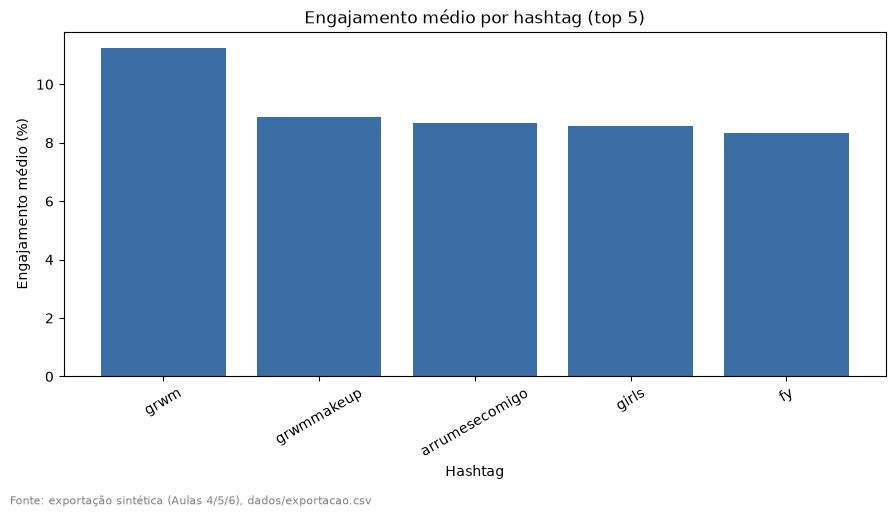

In [12]:
top5 = resumo_hashtags.head(5)  # as 5 hashtags com maior engajamento médio, para o gráfico do relatório de exemplo

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(top5["hashtags"], top5["engajamento_medio"] * 100, color="#3b6ea5")
ax.set_title("Engajamento médio por hashtag (top 5)")
ax.set_xlabel("Hashtag")
ax.set_ylabel("Engajamento médio (%)")
ax.tick_params(axis="x", rotation=30)
fig.text(0.01, -0.02, "Fonte: exportação sintética (Aulas 4/5/6), dados/exportacao.csv", fontsize=8, color="gray")
fig.tight_layout()
plt.savefig("dados/grafico_top5_hashtags.png", dpi=120, bbox_inches="tight")  # salva a figura para poder anexar no relatório
plt.show()

**O que observar:** essa é a mesma tabela e o mesmo tipo de gráfico das Aulas 5 e 6, só que salvos agora em `dados/grafico_top5_hashtags.png`. Um relatório reproduzível salva as figuras que cita, em vez de depender de "printar a tela" da última vez que alguém rodou o notebook.

## 4. A estrutura de um relatório analítico

Um relatório analítico de redes sociais, para este curso, tem seis partes fixas. A ordem importa: cada parte prepara o terreno para a próxima.

1. **Pergunta:** o que você está tentando responder, numa frase. Não é o tema ("hashtags de política"), é uma pergunta que dá para responder com dado ("hashtags de política tiveram engajamento médio maior que as de entretenimento nesta coleta?").
2. **Dados:** de onde vieram (fonte, ferramenta de coleta), o período coletado, o tamanho da amostra e os limites conhecidos (é uma coleta pequena? é só uma plataforma? é só um recorte de hashtag?).
3. **Método:** o que foi calculado e como. Toda fórmula usada (a taxa de engajamento, por exemplo) e toda decisão de tratamento (remoção de duplicata, filtro de denominador zero) entra aqui, mesmo que pareça óbvio.
4. **Achados:** o que os dados mostraram, com evidência (a tabela-resumo, os gráficos). Cada achado deveria caber numa frase apoiada num número ou num gráfico específico.
5. **Limitações:** o que os dados NÃO permitem concluir. Toda coleta pequena, todo recorte de hashtag, toda métrica aproximada (lembra do aviso da Aula 5 sobre não termos alcance nem impressões de verdade?) merece uma frase aqui.
6. **Recomendações:** o que fazer a partir disso, uma decisão prática. É a única parte do relatório que é opinião, e por isso precisa vir claramente separada dos achados, nunca misturada com eles.

**ATENÇÃO:** repare que achados e recomendações são seções diferentes de propósito. Achado é "o que o dado mostra". Recomendação é "o que eu sugiro fazer por causa disso". Se alguém não conseguir apontar, para cada recomendação, qual achado específico a sustenta, ela não é uma recomendação baseada em dado, é uma opinião com aparência de análise.

## 5. Decisões metodológicas: por que registrar cada escolha

Toda análise tem decisões que, se não forem escritas, ficam invisíveis para quem lê o relatório (e às vezes até para quem escreveu, um mês depois). Alguns exemplos do que já apareceu nas Aulas 5 e 6:

- **Por que `plays` como denominador da taxa de engajamento?** Porque o export do Zeeschuimer não traz alcance nem impressões de verdade (essas métricas só existem no painel nativo da plataforma). `plays` foi o denominador disponível mais próximo de "quantas vezes o conteúdo foi exibido". Isso é uma aproximação, não a métrica oficial, e o relatório precisa dizer isso.
- **Por que remover linhas com `plays` igual a zero antes de dividir?** Para não gerar erro de divisão por zero, nem um valor sem sentido (`inf`). Isso também descarta alguns posts da análise: quantos foram descartados é parte do método, não um detalhe escondido.
- **Por que engajamento médio em vez de curtida bruta para ordenar hashtags?** Porque curtida bruta mistura volume com desempenho (lembra do aviso: um autor que posta muito não é o mesmo que um autor que engaja bem). A escolha da métrica muda o ranking, então ela precisa ser explícita.

O teste rápido para saber se uma decisão precisa entrar no método: **se alguém escolhesse diferente (outro denominador, outro corte, outra métrica), o resultado final mudaria?** Se sim, é decisão metodológica e vai para o relatório, sempre.

## 6. Relatório de exemplo, minimalista

Abaixo está um relatório de exemplo, escrito a partir da mesma tabela e do mesmo gráfico gerados nas células acima. Ele é propositalmente curto: um relatório analítico não precisa ser longo para ser completo, precisa ter as seis partes da seção 4 e cada achado apoiado em evidência.

> ### Engajamento por hashtag na coleta de exemplo (TikTok)
>
> **Pergunta:** entre as hashtags que aparecem na coleta, quais têm o maior engajamento médio?
>
> **Dados:** exportação sintética do TikTok via Zeeschuimer (mesmo arquivo usado nas Aulas 5 e 6), 56 posts coletados num recorte de poucos dias em agosto de 2026. Amostra pequena e de uma única plataforma; não representa o TikTok como um todo, só esta coleta específica.
>
> **Método:** removidas linhas duplicadas (nenhuma encontrada) e posts com `plays` igual a zero (nenhum descartado nesta coleta). Taxa de engajamento calculada como `(likes + comments + shares) / plays` por post, depois agrupada por hashtag (uma hashtag por post, coluna `hashtags` separada por vírgula) com a média da taxa de engajamento de cada grupo.
>
> **Achados:**
> - As cinco hashtags com maior engajamento médio estão no gráfico abaixo (`dados/grafico_top5_hashtags.png`), gerado na seção 3 deste notebook.
> - A hashtag no topo do ranking (ver `resumo_hashtags.head(1)`) teve o maior engajamento médio da coleta, mas com poucos posts associados a ela, o que é visível na coluna `qtd_posts` da tabela-resumo.
>
> **Limitações:** a taxa de engajamento usa `plays` como denominador porque o export não traz alcance nem impressões reais da plataforma; é uma aproximação. A coleta cobre poucos dias e um recorte só, então o ranking de hashtags pode mudar bastante numa coleta maior ou em outro período. Hashtags com poucos posts têm médias mais instáveis: um único post viral muda a média inteira do grupo.
>
> **Recomendações:** antes de investir esforço editorial numa hashtag só pelo alto engajamento médio, checar `qtd_posts`: hashtags com 1 ou 2 posts merecem uma coleta maior antes de qualquer decisão. Repetir a coleta em outro período ajudaria a confirmar se o padrão se mantém.

**O que observar nesse exemplo:** a seção de achados nunca diz "portanto devemos usar mais essa hashtag", isso fica isolado na seção de recomendações, e a recomendação explica de qual achado ela depende ("antes de investir... checar qtd_posts"). Repare também que a seção de limitações não é um parágrafo genérico de "os dados têm limitações": cada frase aponta uma limitação específica desta coleta.

## 7. Revisão por pares

Antes de qualquer relatório virar entrega final, ele passa pelos olhos de outra pessoa. Revisar o relatório de um colega não é opinar sobre o texto ("ficou bonito"), é checar um conjunto de critérios objetivos:

- **A pergunta está clara?** Dá para repetir a pergunta com suas próprias palavras depois de ler só a seção "Pergunta"?
- **Os dados batem com o que é dito?** A fonte, o período e o tamanho da amostra descritos na seção "Dados" são os mesmos que aparecem na tabela ou no gráfico anexado?
- **O método está reproduzível?** Alguém que seguisse a seção "Método" chegaria na mesma tabela-resumo, sem adivinhar nenhuma escolha?
- **Cada achado tem evidência?** Toda frase da seção "Achados" aponta para um número, uma linha de tabela ou um gráfico específico, não uma impressão geral?
- **As conclusões extrapolam a evidência?** Alguma frase generaliza além da amostra ("essa hashtag sempre engaja mais", "esse público sempre reage assim") sem os dados sustentarem isso?
- **Achado e recomendação estão separados?** É possível apontar, para cada recomendação, o achado específico de onde ela vem?

Um jeito rápido de aplicar isso: leia o relatório do colega em silêncio, marque cada critério acima com sim/não, e devolva junto com uma frase por "não" explicando o que faltou. Revisão por pares não é reescrever o relatório do colega, é apontar onde ele não se sustenta sozinho.

## 8. Quando der errado

A maior parte dos problemas de um relatório analítico não é erro de código, é erro de raciocínio na hora de escrever a conclusão:

- **Confundir correlação com causalidade:** o gráfico de dispersão da Aula 6 (seguidores vs. engajamento) mostra uma relação, não uma causa. "Contas maiores engajam menos, nesta coleta" é uma leitura válida; "ter mais seguidores causa menos engajamento" não é, um gráfico de dispersão sozinho nunca prova causa.
- **Gráfico sem fonte:** todo gráfico que entra num relatório carrega de onde veio o dado (igual ao `fig.text(...)` usado nas Aulas 6 e nesta aula). Sem isso, quem lê não consegue conferir nem repetir.
- **Conclusão que a amostra não sustenta:** uma coleta de 50 posts de um único recorte não sustenta uma frase do tipo "essa hashtag é a mais forte da plataforma". Sustenta, no máximo, "essa hashtag teve o maior engajamento médio nesta coleta específica".
- **Achado e recomendação misturados no mesmo parágrafo:** se a frase começa descrevendo um número e termina sugerindo uma ação, sem deixar claro onde um vira outro, separe em duas frases, cada uma na sua seção.

E dois erros técnicos comuns nesta etapa:

- **Caminho relativo quebrado ao copiar o notebook para a pasta de entregas:** se o notebook lê `dados/exportacao.csv` e o arquivo não foi copiado junto para dentro da nova pasta, o notebook não roda para quem for conferir. Confira sempre com Kernel → Restart e Run All depois de copiar.
- **Figura salva em branco ou não encontrada:** `plt.savefig(...)` precisa vir **antes** de `plt.show()` (como fizemos na seção 3), porque em alguns ambientes o `plt.show()` já limpa a figura da memória depois de exibi-la.

## Prática: faça agora

Abra `exercicios/exercicio-07-relatorio-analitico.ipynb`. Ele é o **Projeto 2**, a entrega final do módulo, que valerá ponto: você regenera a tabela-resumo e os gráficos com a sua própria coleta (a mesma usada nos exercícios das Aulas 5 e 6, ou alguma diferente, mas aí você precisará fazer tudo de novo) e preenche o template de relatório em `exercicios/RELATORIO-modelo.md` com pergunta, dados, método, achados, limitações e recomendações. Entregue na pasta "projetos/07-relatorio-analitico" no Github.